In [1]:
from torch import nn

In [2]:
model = nn.Linear(in_features=16, out_features=128)

In [3]:
# Xavier
print(model.weight)
nn.init.xavier_uniform_(model.weight, gain=nn.init.calculate_gain('tanh'))
print(model.weight)

Parameter containing:
tensor([[-0.1011,  0.0490, -0.0125,  ...,  0.1874, -0.0914, -0.1751],
        [ 0.2014,  0.2470,  0.2336,  ...,  0.0853,  0.0445,  0.0044],
        [-0.1915, -0.1542, -0.0391,  ..., -0.1479, -0.2285, -0.1525],
        ...,
        [ 0.1628, -0.2065,  0.0037,  ...,  0.0835,  0.0023,  0.0117],
        [ 0.1629,  0.2493, -0.1784,  ..., -0.2428,  0.1263,  0.1347],
        [-0.0217,  0.1435,  0.1343,  ...,  0.1228, -0.1554,  0.2124]],
       requires_grad=True)
Parameter containing:
tensor([[-0.0727, -0.2557,  0.0114,  ...,  0.1530, -0.2523, -0.1979],
        [ 0.2102,  0.2292,  0.2801,  ...,  0.0507,  0.0493,  0.1291],
        [-0.2883, -0.1192, -0.2302,  ..., -0.1910, -0.0041,  0.0120],
        ...,
        [ 0.0234, -0.2644, -0.3215,  ..., -0.2126,  0.2287,  0.2360],
        [ 0.1959,  0.2073, -0.0753,  ...,  0.2613, -0.2660, -0.2865],
        [ 0.0037,  0.0093, -0.2191,  ..., -0.3016,  0.0586,  0.3163]],
       requires_grad=True)


In [4]:
# Kaiming
nn.init.kaiming_uniform_(model.weight, a=1, mode='fan_in', nonlinearity='leaky_relu')
print(model.weight)

Parameter containing:
tensor([[-0.3613, -0.2896,  0.3096,  ...,  0.3478,  0.2207, -0.2061],
        [-0.0641,  0.2979,  0.3962,  ..., -0.3716, -0.3767, -0.3994],
        [ 0.0205, -0.3306,  0.4052,  ...,  0.0674, -0.1845,  0.4176],
        ...,
        [-0.2701, -0.3179,  0.1956,  ...,  0.2323, -0.1273,  0.2445],
        [ 0.1398, -0.1310, -0.2637,  ...,  0.2747,  0.1370,  0.2049],
        [-0.0634, -0.0789,  0.0485,  ..., -0.0638, -0.0008,  0.0347]],
       requires_grad=True)


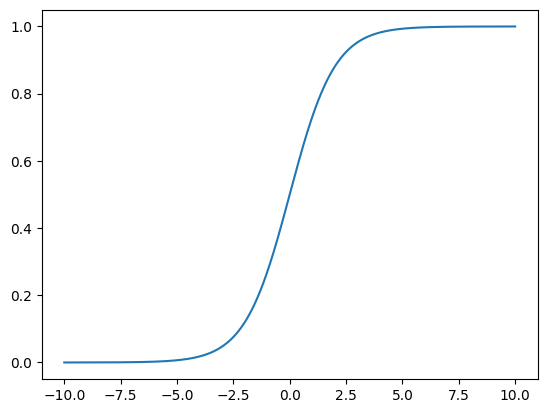

In [5]:
# 画一个Sigmoid激活函数的图像
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 1000)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.show()

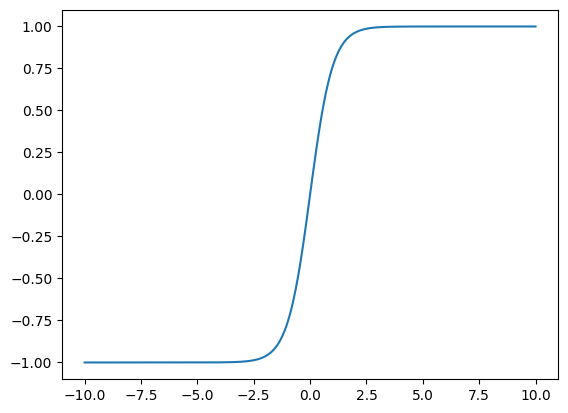

In [6]:
# 画一个tanh函数（双曲正切函数）的图像
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 1000)
y = np.tanh(x)

plt.plot(x, y)
plt.show()

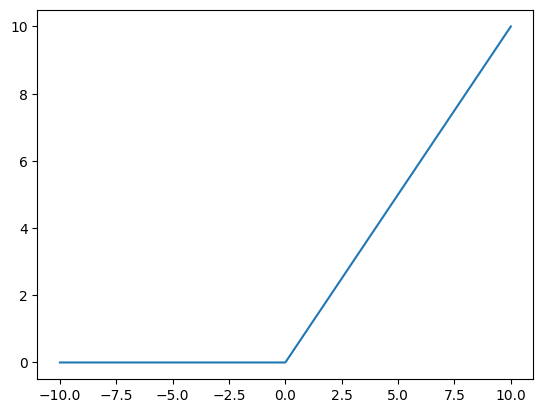

In [7]:
# 画一个ReLU函数的图像
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 1000)
y = np.maximum(0, x)

plt.plot(x, y)
plt.show()

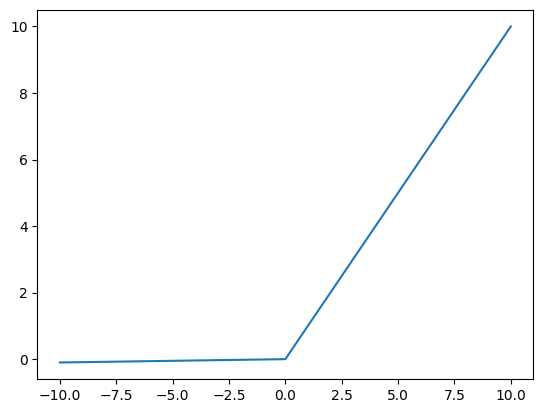

In [8]:
# 画一个Leaky ReLU函数的图像
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 1000)
y = np.maximum(0.01 * x, x)

plt.plot(x, y)
plt.show()

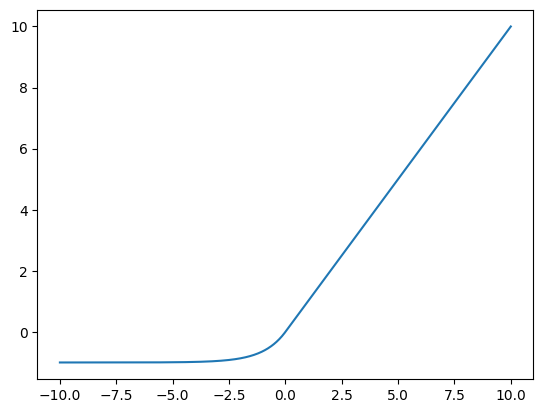

In [13]:
# 画一个ELU (Exponential Linear Units) 函数的图像
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 1000)
# x > 0 时，y = x
# x <= 0 时，y = 0.1 * (e^x - 1)
y = np.where(x > 0, x, 1.0 * (np.exp(x) - 1))

plt.plot(x, y)
plt.show()

In [14]:
import torch
from torch import nn
import torch.nn.functional as F

In [15]:
# define a layer
layer = nn.Linear(in_features=16, out_features=5)
x = torch.randn(size=(8, 16))
layer_output = layer(x)
print(layer_output.size())

torch.Size([8, 5])


In [16]:
# sigmoid
layer_output = F.sigmoid(layer_output)
print(layer_output.size())

torch.Size([8, 5])


In [17]:
# relu: ****
layer_output = F.relu(layer_output)
print(layer_output.size())

torch.Size([8, 5])


In [18]:
# leaky_relu
layer_output = F.leaky_relu(layer_output)
print(layer_output.size())

torch.Size([8, 5])


In [19]:
def mish(x):
    return x*F.tanh(F.softplus(x))

# mish: ****
layer_output = mish(layer_output)
print(layer_output.size())

torch.Size([8, 5])


In [20]:
import torch
from torch import nn
import torch.nn.functional as F

output_from_pre_layer = torch.randn(size=(8, 224, 224, 16)) # RGB image: [224,224,3], NHWC

""" NHWC
N: batch size : 8
H: height: 224,
W: width: 224,
C: channel: 16

NCHW, NHWC
"""

' NHWC\nN: batch size : 8\nH: height: 224,\nW: width: 224,\nC: channel: 16\n\nNCHW, NHWC\n'

In [21]:
""" batch norm
在N 求E(x), Var(x)
适用于大的 batch size
不太适用于变长数据：text, speech
"""
bn_norm = nn.BatchNorm2d(num_features=16) # input shape: NCHW
norm_out = bn_norm(output_from_pre_layer.permute(0, 3, 1, 2)) # NHWC -> NCHW
print('norm from bn', norm_out.shape)

norm from bn torch.Size([8, 16, 224, 224])


In [22]:
""" layer normalization
在[224,224,16]求E(x), Var(x)
对batch size 不敏感， 适用sequence data(序列变长的数据): RNN/Transformer
"""
ln_norm = nn.LayerNorm([224, 224, 16]) # input shape: [N, *]
norm_out = ln_norm(output_from_pre_layer)
print('norm from ln', norm_out.shape)

norm from ln torch.Size([8, 224, 224, 16])


In [23]:
""" instance normalization
在channel 这个维度上求的E(x), Var(x)
适用GAN(生成式神经网络)
"""
in_norm = nn.InstanceNorm2d(16) # input shape: NCHW
norm_out = in_norm(output_from_pre_layer.permute(0, 3, 1, 2))
print('norm from in', norm_out.shape)

""" group normalization
在分组后的group上求的E(x), Var(x): [224, 224, group_number， 16/group_number]
group number: 需要精心设置
"""
gn_norm = nn.GroupNorm(num_groups=4, num_channels=16) # input shape: (N, C, *)
norm_out = gn_norm(output_from_pre_layer.permute(0, 3, 1, 2))
print('norm from gn', norm_out.shape)

final_output = F.relu(norm_out)

norm from in torch.Size([8, 16, 224, 224])
norm from gn torch.Size([8, 16, 224, 224])


In [25]:
import torch
from torch import nn
from torch.nn import functional as F

# 定义一个device，决定是否使用cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# fake data
n_item = 1000
n_feature = 2

torch.manual_seed(123)
data_x = torch.randn(size=(n_item, n_feature)).float()
data_y = torch.where(torch.subtract(data_x[:, 0]*0.5, data_x[:, 1]*1.5)+0.02 > 0, 0, 1).long()

data_y = F.one_hot(data_y)  # one hot encode
""" shape: [n_item, 2]
tensor([[1, 0],
        [1, 0],
        [0, 1],
        ...,
        [1, 0],
        [1, 0],
        [1, 0]])
"""

class BinaryClassificationModel(nn.Module):
    def __init__(self, in_feature):
        super(BinaryClassificationModel, self).__init__()
        """ single perceptron 
        self.layer_1 = nn.Linear(in_features=in_feature, out_features=2, bias=True)
        """

        """ multi perceptron """
        self.layer_1 = nn.Linear(in_features=in_feature, out_features=128, bias=True)
        self.layer_2 = nn.Linear(in_features=128, out_features=512, bias=True)
        # 。。。
        self.layer_final = nn.Linear(in_features=512, out_features=2, bias=True)

    def forward(self, x):
        layer_1_output = F.sigmoid(self.layer_1(x))
        layer_2_output = F.sigmoid(self.layer_2(layer_1_output))
        output = F.sigmoid(self.layer_final(layer_2_output))
        return output

# hyper parameters
learning_rate = 0.01
epochs = 100

model = BinaryClassificationModel(n_feature).to(device)

opt = torch.optim.SGD(model.parameters(), lr=learning_rate)

criteria = nn.BCELoss()

# train loop
lambda_l1 = 0.01
lambda_l2 = 0.0001
for epoch in range(1000):
    for step in range(n_item):
        x = data_x[step].to(device)
        y = data_y[step].to(device)

        opt.zero_grad()

        y_hat = model(x.unsqueeze(0)) # [1, 2]

        layer_1_w = torch.cat([x.view(-1) for p in model.layer_1.parameters()]) # flatten: [2: 3] -> (6,)
        layer_2_w = torch.cat([x.view(-1) for p in model.layer_2.parameters()])
        layer_final_w = torch.cat([x.view(-1) for p in model.layer_final.parameters()])
        all_weights = torch.cat([layer_1_w, layer_2_w, layer_final_w], dim=-1)
        l2_norm = torch.norm(all_weights, p=2)

        # [1, 2]: [[0.9, 0.1]]
        loss = criteria(y_hat, y.unsqueeze(0).float()) + lambda_l2*l2_norm

        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print('Epoch: %03d, Loss: %.3f' % (epoch, loss.cpu().item()))


Epoch: 000, Loss: 0.360
Epoch: 050, Loss: 0.008
Epoch: 100, Loss: 0.001
Epoch: 150, Loss: 0.000
Epoch: 200, Loss: 0.000
Epoch: 250, Loss: 0.000
Epoch: 300, Loss: 0.000
Epoch: 350, Loss: 0.000
Epoch: 400, Loss: 0.000
Epoch: 450, Loss: 0.000
Epoch: 500, Loss: 0.000
Epoch: 550, Loss: 0.000
Epoch: 600, Loss: 0.000
Epoch: 650, Loss: 0.000
Epoch: 700, Loss: 0.000
Epoch: 750, Loss: 0.000
Epoch: 800, Loss: 0.000
Epoch: 850, Loss: 0.000
Epoch: 900, Loss: 0.000
Epoch: 950, Loss: 0.000
